In [3]:
# Download the required model files for face, age, and gender detection
# Face detector models (these links previously worked successfully)
!wget -N https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20180220_uint8/opencv_face_detector_uint8.pb
!wget -N https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!mv deploy.prototxt opencv_face_detector.pbtxt

# Corrected URLs for age and gender models from dataduodenum/age-gender-estimation repository
!wget -N https://raw.githubusercontent.com/dataduodenum/age-gender-estimation/master/models/age_net.caffemodel
!wget -N https://raw.githubusercontent.com/dataduodenum/age-gender-estimation/master/models/age_deploy.prototxt

!wget -N https://raw.githubusercontent.com/dataduodenum/age-gender-estimation/master/models/gender_net.caffemodel
!wget -N https://raw.githubusercontent.com/dataduodenum/age-gender-estimation/master/models/gender_deploy.prototxt

print("Model files downloaded successfully.")

--2026-05-21 11:44:57--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20180220_uint8/opencv_face_detector_uint8.pb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2727750 (2.6M) [application/octet-stream]
Saving to: ‘opencv_face_detector_uint8.pb’

opencv_face_detecto 100%[===================>]   2.60M  --.-KB/s    in 0.01s   

Last-modified header missing -- time-stamps turned off.
2026-05-21 11:44:57 (218 MB/s) - ‘opencv_face_detector_uint8.pb’ saved [2727750/2727750]

--2026-05-21 11:44:57--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting

In [4]:
# Unzip the provided archive, which should contain the age and gender models.
!unzip -o /content/Gender-and-Age-Detection-master.zip

# List the contents of the unzipped directory to find the model paths
!ls -R /content/Gender-and-Age-Detection-master/

Archive:  /content/Gender-and-Age-Detection-master.zip
   creating: Gender-and-Age-Detection-master/
  inflating: __MACOSX/._Gender-and-Age-Detection-master  
  inflating: Gender-and-Age-Detection-master/.DS_Store  
  inflating: __MACOSX/Gender-and-Age-Detection-master/._.DS_Store  
  inflating: Gender-and-Age-Detection-master/LICENSE  
  inflating: __MACOSX/Gender-and-Age-Detection-master/._LICENSE  
  inflating: Gender-and-Age-Detection-master/opencv_face_detector_uint8.pb  
  inflating: __MACOSX/Gender-and-Age-Detection-master/._opencv_face_detector_uint8.pb  
  inflating: Gender-and-Age-Detection-master/kid1.jpg  
  inflating: __MACOSX/Gender-and-Age-Detection-master/._kid1.jpg  
   creating: Gender-and-Age-Detection-master/Example/
  inflating: __MACOSX/Gender-and-Age-Detection-master/._Example  
  inflating: Gender-and-Age-Detection-master/age_deploy.prototxt  
  inflating: __MACOSX/Gender-and-Age-Detection-master/._age_deploy.prototxt  
  inflating: Gender-and-Age-Detection-mast

Gender: Female
Age: 4-6 years


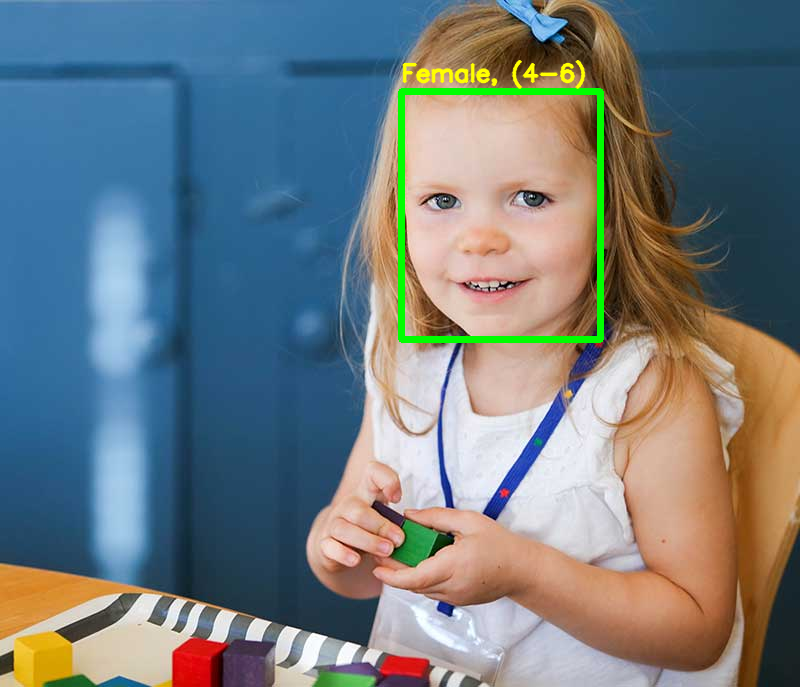

In [5]:
import cv2
import math
from google.colab.patches import cv2_imshow # Import for displaying images in Colab

def highlightFace(net, frame, conf_threshold=0.7):
    frameOpencvDnn=frame.copy()
    frameHeight=frameOpencvDnn.shape[0]
    frameWidth=frameOpencvDnn.shape[1]
    blob=cv2.dnn.blobFromImage(frameOpencvDnn, 1.0, (300, 300), [104, 117, 123], True, False)

    net.setInput(blob)
    detections=net.forward()
    faceBoxes=[]
    for i in range(detections.shape[2]):
        confidence=detections[0,0,i,2]
        if confidence>conf_threshold:
            x1=int(detections[0,0,i,3]*frameWidth)
            y1=int(detections[0,0,i,4]*frameHeight)
            x2=int(detections[0,0,i,5]*frameWidth)
            y2=int(detections[0,0,i,6]*frameHeight)
            faceBoxes.append([x1,y1,x2,y2])
            cv2.rectangle(frameOpencvDnn, (x1,y1), (x2,y2), (0,255,0), int(round(frameHeight/150)), 8)
    return frameOpencvDnn,faceBoxes

# Removed argparse as we're now processing a static image

faceProto="/content/Gender-and-Age-Detection-master/opencv_face_detector.pbtxt"
faceModel="/content/Gender-and-Age-Detection-master/opencv_face_detector_uint8.pb"
ageProto="/content/Gender-and-Age-Detection-master/age_deploy.prototxt"
ageModel="/content/Gender-and-Age-Detection-master/age_net.caffemodel"
genderProto="/content/Gender-and-Age-Detection-master/gender_deploy.prototxt"
genderModel="/content/Gender-and-Age-Detection-master/gender_net.caffemodel"

MODEL_MEAN_VALUES=(78.4263377603, 87.7689143744, 114.895847746)
ageList=['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)', '(48-53)', '(60-100)']
genderList=['Male','Female']

faceNet=cv2.dnn.readNet(faceModel,faceProto)
ageNet=cv2.dnn.readNet(ageModel,ageProto)
genderNet=cv2.dnn.readNet(genderModel,genderProto)

# Load a static image instead of video stream
image_path = '/content/kid2.jpg' # Using an example image
frame = cv2.imread(image_path)

if frame is None:
    print(f"Error: Could not load image from {image_path}")
else:
    padding=20

    resultImg,faceBoxes=highlightFace(faceNet,frame)
    if not faceBoxes:
        print("No face detected")

    for faceBox in faceBoxes:
        face=frame[max(0,faceBox[1]-padding):
                   min(faceBox[3]+padding,frame.shape[0]-1),max(0,faceBox[0]-padding)
                   :min(faceBox[2]+padding, frame.shape[1]-1)]

        blob=cv2.dnn.blobFromImage(face, 1.0, (227,227), MODEL_MEAN_VALUES, swapRB=False)
        genderNet.setInput(blob)
        genderPreds=genderNet.forward()
        gender=genderList[genderPreds[0].argmax()]
        print(f'Gender: {gender}')

        ageNet.setInput(blob)
        agePreds=ageNet.forward()
        age=ageList[agePreds[0].argmax()]
        print(f'Age: {age[1:-1]} years')

        cv2.putText(resultImg, f'{gender}, {age}', (faceBox[0], faceBox[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2, cv2.LINE_AA)

    # Display the result image in Colab
    cv2_imshow(resultImg)
